In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# Data processing & modeling
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_curve, RocCurveDisplay
# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
# Dataset link : https://www.kaggle.com/datasets/shahriarkabir/procurement-kpi-analysis-dataset

df_raw = pd.read_csv('Procurement KPI Analysis Dataset.csv')
# Create a copy
df = df_raw.copy()

df.columns = df.columns.str.lower().str.replace(' ', '_', regex=False)
print("--- Standardized Column Names ---")
print(df.columns.tolist())

--- Standardized Column Names ---
['po_id', 'supplier', 'order_date', 'delivery_date', 'item_category', 'order_status', 'quantity', 'unit_price', 'negotiated_price', 'defective_units', 'compliance']


In [ ]:
# --- 2. Handle Data Types ---
# Convert date columns to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')

# Verify date conversion
print(df[['order_date', 'delivery_date']].dtypes)

order_date       datetime64[ns]
delivery_date    datetime64[ns]
dtype: object


In [ ]:
# --- 3. Handle Missing Values ---
# Fill missing Defective_Units with 0 (assuming NaN means no defects reported)
df['defective_units'].fillna(0, inplace=True)
print(f"\nFilled missing 'defective_units' with 0. Remaining NaNs: {df['defective_units'].isnull().sum()}")

# Handle missing Negotiated_Price. Strategy: Impute with the Unit_Price for that row (assuming no negotiation occurred or wasn't recorded).
missing_negotiated_idx = df[df['negotiated_price'].isnull()].index
if not missing_negotiated_idx.empty:
    print(f"\nFound {len(missing_negotiated_idx)} missing 'negotiated_price'. Imputing with 'unit_price'.")
    df.loc[missing_negotiated_idx, 'negotiated_price'] = df.loc[missing_negotiated_idx, 'unit_price']
print(f"Remaining NaNs in 'negotiated_price': {df['negotiated_price'].isnull().sum()}")

# Delivery_Date NaNs will be handled during feature engineering (lead time calculation).



Filled missing 'defective_units' with 0. Remaining NaNs: 0
Remaining NaNs in 'negotiated_price': 0


In [ ]:
# --- 1. Calculate Lead Time ---
# Difference between delivery and order date in days
# NaT (Not a Time) will result if delivery_date is NaN
df['lead_time_days'] = (df['delivery_date'] - df['order_date']).dt.days
print("\n--- Lead Time Calculation ---")
print(f"Lead time calculated. Min: {df['lead_time_days'].min()}, Max: {df['lead_time_days'].max()}, Mean: {df['lead_time_days'].mean():.2f}")
print(f"Number of POs with missing lead time (due to missing delivery_date): {df['lead_time_days'].isnull().sum()}")


--- Lead Time Calculation ---
Lead time calculated. Min: -5.0, Max: 20.0, Mean: 10.78
Number of POs with missing lead time (due to missing delivery_date): 87


In [ ]:
# --- 2. Calculate Costs and Savings ---
df['total_value_unit'] = df['quantity'] * df['unit_price']
df['total_value_negotiated'] = df['quantity'] * df['negotiated_price']
df['cost_savings'] = df['total_value_unit'] - df['total_value_negotiated']

# Calculate Savings Percentage (handle potential division by zero if unit_price is 0)
df['cost_savings_perc'] = np.where(
    df['unit_price'] > 0,
    ((df['unit_price'] - df['negotiated_price']) / df['unit_price']) * 100,
    0  # Assign 0% savings if unit price is 0 or less
)
# Ensure savings aren't negative due to potential data errors handled earlier
df['cost_savings'] = df['cost_savings'].clip(lower=0)
df['cost_savings_perc'] = df['cost_savings_perc'].clip(lower=0)

print("\n--- Cost & Savings Calculation ---")
print(f"Total Cost Savings across all POs: ${df['cost_savings'].sum():,.2f}")
print(f"Average Cost Savings Percentage: {df['cost_savings_perc'].mean():.2f}%")


--- Cost & Savings Calculation ---
Total Cost Savings across all POs: $3,931,126.47
Average Cost Savings Percentage: 7.97%


In [ ]:
# --- 3. Calculate Defect Rate ---
# Percentage of defective units relative to quantity ordered
# Handle potential division by zero if quantity is 0
df['defect_rate_perc'] = np.where(
    df['quantity'] > 0,
    (df['defective_units'] / df['quantity']) * 100,
    0 # Assign 0% defect rate if quantity is 0
)
print("\n--- Defect Rate Calculation ---")
print(f"Average Defect Rate: {df['defect_rate_perc'].mean():.2f}%")
print(f"Max Defect Rate: {df['defect_rate_perc'].max():.2f}%")


--- Defect Rate Calculation ---
Average Defect Rate: 5.78%
Max Defect Rate: 35.71%


In [ ]:
# --- 4. Extract Time Features ---
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.to_period('Q') # Quarter object
df['order_year_month'] = df['order_date'].dt.to_period('M') # Year-Month object
print("\nExtracted Year, Month, Quarter from Order Date.")


Extracted Year, Month, Quarter from Order Date.


In [ ]:
# --- 5. Define On-Time Delivery Status (Example Heuristic) ---
# This requires a definition of 'on-time'. Let's use a threshold based on typical lead times,
# or analyze lead times by category/supplier first.
# For now, let's create a flag for whether delivery occurred *at all* based on non-NaN delivery_date
df['delivery_occurred'] = df['delivery_date'].notna()

# We can also analyze lead times relative to a benchmark later in EDA.
# Example: Calculate median lead time per item category
# median_lead_times = df.groupby('item_category')['lead_time_days'].median()
# df['median_lead_time_category'] = df['item_category'].map(median_lead_times)
# df['is_late'] = df['lead_time_days'] > df['median_lead_time_category']

print("\nCreated 'delivery_occurred' flag.")

# Display dataframe with new features
print("\n--- DataFrame with Engineered Features (Sample) ---")
print(df.head())


Created 'delivery_occurred' flag.

--- DataFrame with Engineered Features (Sample) ---
      po_id         supplier order_date delivery_date    item_category  \
0  PO-00001        Alpha_Inc 2023-10-17    2023-10-25  Office Supplies   
1  PO-00002  Delta_Logistics 2022-04-25    2022-05-05  Office Supplies   
2  PO-00003         Gamma_Co 2022-01-26    2022-02-15              MRO   
3  PO-00004    Beta_Supplies 2022-10-09    2022-10-28        Packaging   
4  PO-00005  Delta_Logistics 2022-09-08    2022-09-20    Raw Materials   

  order_status  quantity  unit_price  negotiated_price  defective_units  ...  \
0    Cancelled      1176       20.13             17.81              0.0  ...   
1    Delivered      1509       39.32             37.34            235.0  ...   
2    Delivered       910       95.51             92.26             41.0  ...   
3    Delivered      1344       99.85             95.52            112.0  ...   
4    Delivered      1180       64.07             60.53            1

In [ ]:
# ---- 1. Separate features / target ----------------------------------
features_for_model = [
    'supplier', 'item_category', 'quantity', 'unit_price', 'negotiated_price',
    'order_year', 'order_month', 'compliance'
]
target_for_model = 'delivery_occurred'

cat_cols = ['supplier', 'item_category', 'compliance']
num_cols = [c for c in features_for_model if c not in cat_cols]

X = df[features_for_model].copy()
y = df[target_for_model]

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
# ---- 2. Encode categorical columns as integers ----------------------
oe = OrdinalEncoder()
X_cat_enc = oe.fit_transform(X[cat_cols])          # shape (n_samples, 3)
X_num     = X[num_cols].values                     # shape (n_samples, 5)

X_enc = np.hstack([X_cat_enc, X_num])              # combined matrix
cat_indices = list(range(len(cat_cols)))           # [0, 1, 2]


In [ ]:
from imblearn.over_sampling import SMOTENC
# ---- 3. SMOTENC oversampling ----------------------------------------
smote = SMOTENC(categorical_features=cat_indices,
                random_state=42,
                sampling_strategy='auto')          # balance the classes

X_res, y_res = smote.fit_resample(X_enc, y)        # synthetic data added

# ---- 4. Decode encoded categoricals back to original strings --------
X_cat_dec = oe.inverse_transform(X_res[:, :len(cat_cols)])
X_num_res = X_res[:, len(cat_cols):]

# ---- 5. Build the balanced DataFrame --------------------------------
df_balanced = pd.DataFrame(X_cat_dec, columns=cat_cols)
for i, col in enumerate(num_cols):
    df_balanced[col] = X_num_res[:, i]
df_balanced[target_for_model] = y_res.values

# df_balanced is now the oversampled dataset
print(df[target_for_model].value_counts(), "\n--- before")
print(df_balanced[target_for_model].value_counts(), "--- after")

delivery_occurred
True     690
False     87
Name: count, dtype: int64 
--- before
delivery_occurred
True     690
False    690
Name: count, dtype: int64 --- after


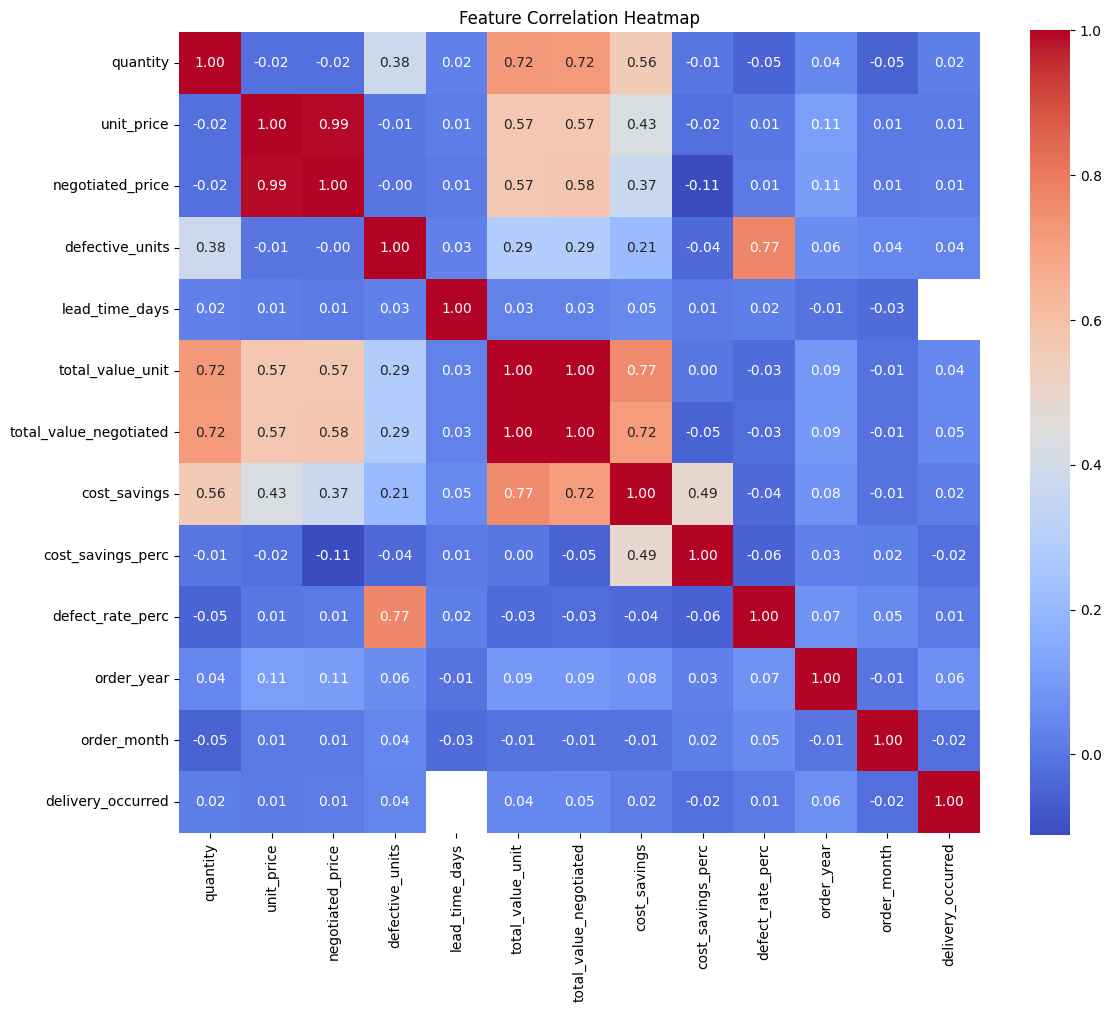

In [ ]:
#copy all the columns without po_id
df_m = df.drop(columns=['po_id'])

# Calculate correlation matrix
corr = df_m.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# 1. Prepare Data for Modeling  (using the SMOTE-balanced DataFrame)
# -------------------------------------------------------------------------
features_for_model = [
    'supplier', 'item_category', 'quantity', 'unit_price', 'negotiated_price',
    'order_year', 'order_month', 'compliance'
]
target_for_model = 'delivery_occurred'

X = df_balanced[features_for_model]
y = df_balanced[target_for_model]          # <-- CHANGED (use balanced labels)

print("Balanced class counts:\n", y.value_counts())

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)            # 1 = Yes, 0 = No
print("\nTarget mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Identify feature types
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features   = X.select_dtypes(include=np.number).columns.tolist()

print(f"\nCategorical Features: {categorical_features}")
print(f"Numerical  Features: {numerical_features}")


Balanced class counts:
 delivery_occurred
True     690
False    690
Name: count, dtype: int64

Target mapping: {np.False_: np.int64(0), np.True_: np.int64(1)}

Categorical Features: ['supplier', 'item_category', 'compliance']
Numerical  Features: ['quantity', 'unit_price', 'negotiated_price', 'order_year', 'order_month']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

label_names = [str(c) for c in le.classes_]



Accuracy: 0.8587
              precision    recall  f1-score   support

       False       0.88      0.83      0.85       138
        True       0.84      0.89      0.86       138

    accuracy                           0.86       276
   macro avg       0.86      0.86      0.86       276
weighted avg       0.86      0.86      0.86       276



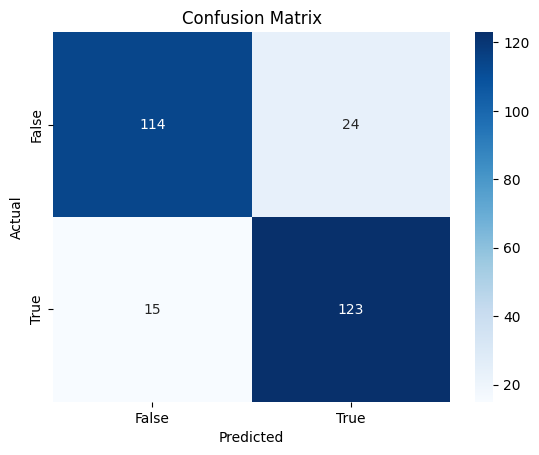

In [ ]:
pipeline_ml = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

pipeline_ml.fit(X_train, y_train)

y_pred = pipeline_ml.predict(X_test)
try:
    y_prob = pipeline_ml.predict_proba(X_test)[:, 1]
except AttributeError:
    y_prob = None

accuracy = accuracy_score(y_test, y_pred)
report   = classification_report(
    y_test, y_pred,
    target_names=label_names,
    zero_division=0
    )
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(report)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:49:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8949
              precision    recall  f1-score   support

       False       0.92      0.87      0.89       138
        True       0.88      0.92      0.90       138

    accuracy                           0.89       276
   macro avg       0.90      0.89      0.89       276
weighted avg       0.90      0.89      0.89       276



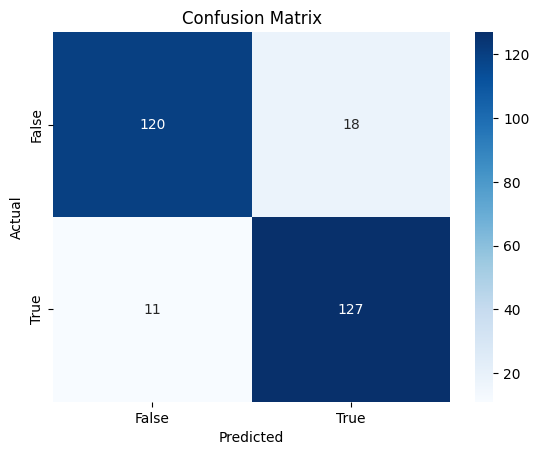

In [ ]:
pipeline_ml = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(use_label_encoder=False,
                                         eval_metric='logloss',
                                         random_state=42))
    ])

pipeline_ml.fit(X_train, y_train)

y_pred = pipeline_ml.predict(X_test)
try:
    y_prob = pipeline_ml.predict_proba(X_test)[:, 1]
except AttributeError:
    y_prob = None

accuracy = accuracy_score(y_test, y_pred)
report   = classification_report(
    y_test, y_pred,
    target_names=label_names,
    zero_division=0
    )
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(report)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


Accuracy: 0.8804
              precision    recall  f1-score   support

       False       0.93      0.82      0.87       138
        True       0.84      0.94      0.89       138

    accuracy                           0.88       276
   macro avg       0.89      0.88      0.88       276
weighted avg       0.89      0.88      0.88       276



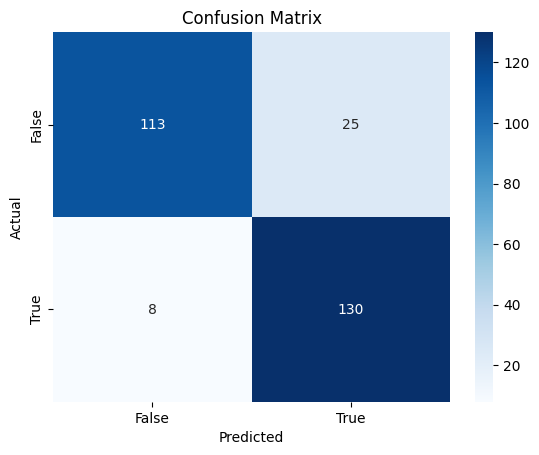

In [ ]:
pipeline_ml = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ])

pipeline_ml.fit(X_train, y_train)

y_pred = pipeline_ml.predict(X_test)
try:
    y_prob = pipeline_ml.predict_proba(X_test)[:, 1]
except AttributeError:
    y_prob = None

accuracy = accuracy_score(y_test, y_pred)
report   = classification_report(
    y_test, y_pred,
    target_names=label_names,
    zero_division=0
    )
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(report)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


Accuracy: 0.7862
              precision    recall  f1-score   support

       False       0.83      0.72      0.77       138
        True       0.75      0.85      0.80       138

    accuracy                           0.79       276
   macro avg       0.79      0.79      0.79       276
weighted avg       0.79      0.79      0.79       276



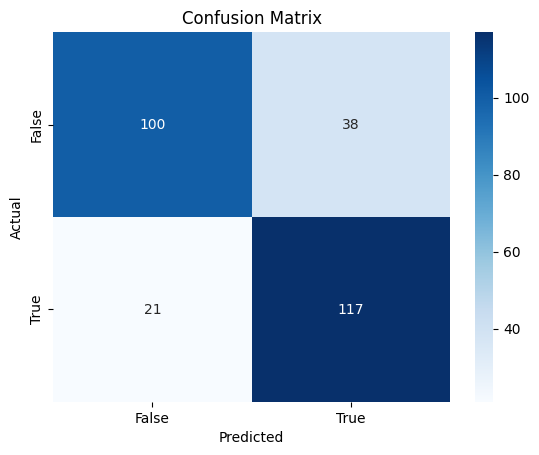

In [ ]:
pipeline_ml = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', AdaBoostClassifier(random_state=42))
    ])

pipeline_ml.fit(X_train, y_train)

y_pred = pipeline_ml.predict(X_test)
try:
    y_prob = pipeline_ml.predict_proba(X_test)[:, 1]
except AttributeError:
    y_prob = None

accuracy = accuracy_score(y_test, y_pred)
report   = classification_report(
    y_test, y_pred,
    target_names=label_names,
    zero_division=0
    )
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(report)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
